# 03 Image Features and Multi-Source Data Evaluation

This notebook evaluates the information and predictive value of
handcrafted ROI image features for PM2.5 estimation and investigates
whether combining image, reanalysis, local meteorological, and temporal
predictors improves performance.

All feature and data-source evaluations are conducted exclusively on the
development set using date-grouped cross-validation. The common
date-disjoint hold-out set is not used and remains reserved for the final
model benchmark.

Ridge regression and Random Forest are used as analytical models to
compare feature configurations. They are not treated as the final model
selection benchmark.

**Input:** `data/processed/final_dataset.csv`

**Output:** `results/feature_evaluation/`

## Research Questions

**RQ1.** Can handcrafted ROI image features effectively represent PM2.5
variations?

**RQ2.** Does multi-source data fusion improve PM2.5 estimation compared
with using ROI image features alone?

## Workflow Overview

1. Dataset and evaluation protocol
2. Handcrafted ROI image feature evaluation
3. Multi-source fusion and source ablation

## Setup

In [3]:
import sys
import importlib
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

def find_project_root(start_path=None):
    """Find the nearest parent containing the project source and notebooks."""
    start = Path.cwd() if start_path is None else Path(start_path)
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing src/ and notebooks/."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results" / "feature_evaluation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Data processing
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Project models
import src.config as config
import src.plot_style as plot_style

importlib.reload(plot_style)
COLORS = plot_style.COLORS
plot_style.apply_thesis_style()
importlib.reload(config)

import src.features.plots as features_plots
importlib.reload(features_plots)

import src.features.evaluation as evaluation
importlib.reload(evaluation)

# Models used for feature evaluation
from sklearn.dummy import DummyRegressor


## 1. Dataset and Evaluation Setup

This section describes the complete-case dataset and defines the
date-disjoint evaluation protocol.

In [4]:
# Load and validate the processed dataset

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "final_dataset.csv"
)

df = (
    pd.read_csv(
        DATA_PATH,
        parse_dates=["time"],
    )
    .sort_values("time")
    .reset_index(drop=True)
)

TARGET = config.TARGET
ALL_FEATURES = config.ALL_FEATURES

if len(ALL_FEATURES) != len(set(ALL_FEATURES)):
    raise ValueError("ALL_FEATURES contains duplicate variables.")

required_columns = [
    "time",
    TARGET,
    *ALL_FEATURES,
]

missing_columns = sorted(
    set(required_columns)
    - set(df.columns)
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

feature_summary = pd.DataFrame(
    {
        "Feature group": [
            *config.FEATURE_GROUPS,
            "Total",
        ],
        "Variables": [
            *[
                len(features)
                for features
                in config.FEATURE_GROUPS.values()
            ],
            len(ALL_FEATURES),
        ],
    }
)

display(feature_summary)

,Feature group,Variables
0,Image,18
1,ERA5,18
2,ARPA,7
3,Temporal,12
4,Total,55


In [5]:
# Prepare the complete-case analysis dataset

analysis_df = (
    df[required_columns]
    .dropna()
    .sort_values("time")
    .reset_index(drop=True)
)

analysis_df["date_group"] = (
    analysis_df["time"]
    .dt.normalize()
)

preparation_summary = pd.DataFrame(
    {
        "Item": [
            "Original samples",
            "Complete-case samples",
            "Removed incomplete samples",
            "Independent dates",
            "Start time",
            "End time",
        ],
        "Value": [
            len(df),
            len(analysis_df),
            len(df) - len(analysis_df),
            analysis_df["date_group"].nunique(),
            analysis_df["time"].min(),
            analysis_df["time"].max(),
        ],
    }
)

display(preparation_summary)

,Item,Value
0,Original samples,3625
1,Complete-case samples,3625
2,Removed incomplete samples,0
3,Independent dates,209
4,Start time,2025-01-29 15:00:00
5,End time,2026-08-12 21:00:00


### 1.1 Complete-Dataset PM2.5 Distribution and Temporal Coverage

This descriptive analysis summarizes the PM2.5 distribution, temporal
coverage, monthly variability, and concentration-range representation
of the complete-case dataset. No feature or model evaluation is
performed in this section.

In [6]:
# Complete-dataset PM2.5 summary

pm25_summary = pd.DataFrame(
    {
        "Observations": [len(analysis_df)],
        "Independent dates": [
            analysis_df["date_group"].nunique()
        ],
        "Mean": [analysis_df[TARGET].mean()],
        "Median": [analysis_df[TARGET].median()],
        "Std": [analysis_df[TARGET].std()],
        "Q1": [analysis_df[TARGET].quantile(0.25)],
        "Q3": [analysis_df[TARGET].quantile(0.75)],
        "Maximum": [analysis_df[TARGET].max()],
        "Skewness": [analysis_df[TARGET].skew()],
    }
)

display(pm25_summary.round(2))

# PM2.5 concentration-range coverage

concentration_order = ["≤20", "20–35", ">35"]

concentration_df = analysis_df.assign(
    concentration_range=pd.cut(
        analysis_df[TARGET],
        bins=[-np.inf, 20, 35, np.inf],
        labels=concentration_order,
    )
)

concentration_summary = (
    concentration_df
    .groupby("concentration_range", observed=False)
    .agg(
        Samples=(TARGET, "size"),
        Independent_dates=("date_group", "nunique"),
    )
    .reindex(concentration_order)
    .reset_index()
    .rename(
        columns={
            "concentration_range": "PM2.5 range",
            "Independent_dates": "Independent dates",
        }
    )
)

concentration_summary["Samples (%)"] = (
    concentration_summary["Samples"]
    / len(analysis_df)
    * 100
)

display(concentration_summary.round(1))

,Observations,Independent dates,Mean,Median,Std,Q1,Q3,Maximum,Skewness
0,3625,209,14.55,11.23,11.35,7.23,17.8,93.11,1.85


,PM2.5 range,Samples,Independent dates,Samples (%)
0,≤20,2899,189,80.0
1,20–35,460,110,12.7
2,>35,266,31,7.3


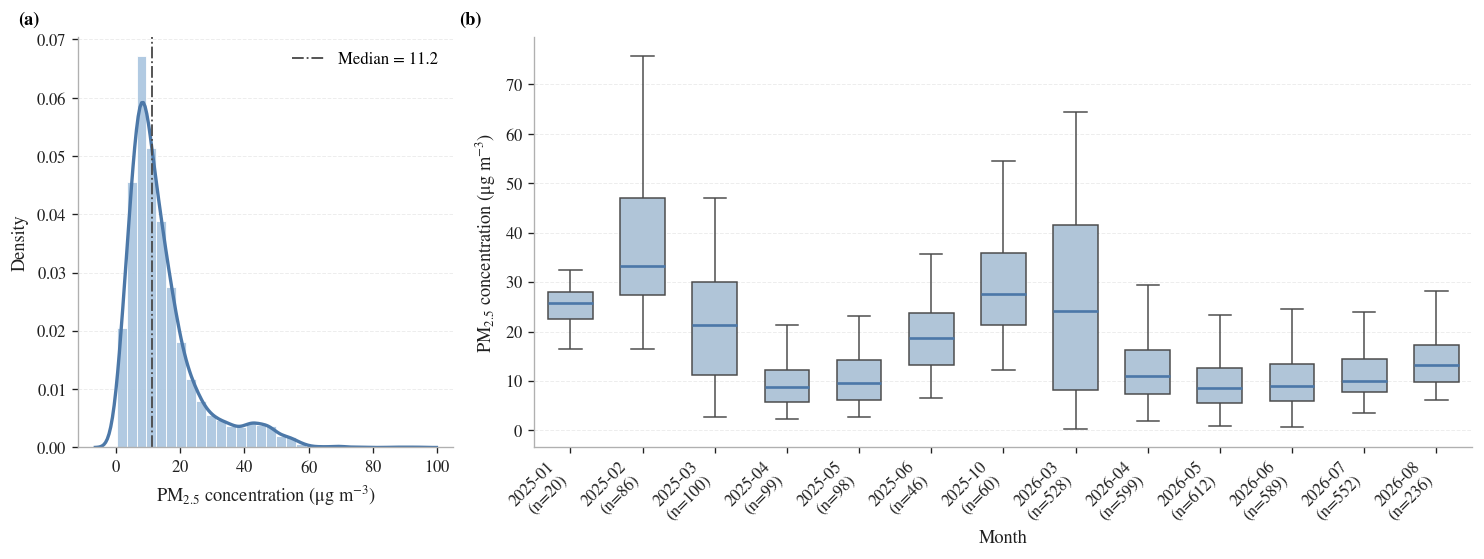

In [7]:
# Prepare monthly data

monthly_df = analysis_df.copy()
monthly_df["year_month"] = (
    monthly_df["time"]
    .dt.to_period("M")
    .astype(str)
)

# Complete-dataset overall and monthly PM2.5 distributions

fig, axes = features_plots.plot_pm25_distribution_and_monthly_distributions(
    data=monthly_df,
    target=TARGET,
    output_path=(
        RESULTS_DIR / "pm25_distribution_and_monthly_distributions.png"
    ),
)

plt.show()

### 1.2 Feature-Evaluation Protocol

The complete-case dataset is divided into date-disjoint development and
common hold-out subsets. Complete dates are assigned to only one subset.

All feature and data-source evaluations in Sections 2 and 3 use
unweighted, date-grouped cross-validation within the development set.
The common hold-out is included only in the complete-dataset description
in Section 1.1 and is otherwise reserved for final evaluation in
Notebooks 4 and 5.

In [8]:
# Evaluation settings

FINAL_TEST_SIZE = 0.20
N_SPLITS = 5

SPLIT_RANDOM_STATE = 24
MODEL_RANDOM_STATE = 42

# Create the development and common hold-out subsets

development_df, final_test_df = (
    evaluation.balanced_month_group_split(
        analysis_df,
        time_column="time",
        test_size=FINAL_TEST_SIZE,
        random_state=SPLIT_RANDOM_STATE,
    )
)

development_dates = set(
    development_df["date_group"]
)

final_test_dates = set(
    final_test_df["date_group"]
)

shared_dates = (
    development_dates
    & final_test_dates
)

assert len(shared_dates) == 0

split_summary = pd.DataFrame(
    {
        "Subset": [
            "Development",
            "Common hold-out",
        ],
        "Samples": [
            len(development_df),
            len(final_test_df),
        ],
        "Independent dates": [
            development_df["date_group"].nunique(),
            final_test_df["date_group"].nunique(),
        ],
    }
)

split_summary["Percentage"] = (
    split_summary["Samples"]
    / len(analysis_df)
    * 100
)

display(
    split_summary.round(
        {"Percentage": 1}
    )
)

print(
    "Shared dates:",
    len(shared_dates),
)

split_summary.to_csv(
    RESULTS_DIR / "split_summary.csv",
    index=False,
)

,Subset,Samples,Independent dates,Percentage
0,Development,2905,167,80.1
1,Common hold-out,720,42,19.9


Shared dates: 0


## 2. Handcrafted ROI Image Feature Evaluation

This section examines the distributions, PM2.5 associations, and
predictive value of handcrafted features extracted from the fixed ROI.

### 2.1 Feature Distributions

Standardized distributions are used to compare feature scales and
variability. Standardization is applied for visualization only.

In [9]:
# Summary statistics of ROI image features

roi_summary = (
    development_df[config.IMAGE_FEATURES]
    .describe()
    .T[
        ["mean","std","min","25%","50%","75%","max",]
    ]
    .round(2)
    .rename(
        columns={
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "25%": "Q1",
            "50%": "Median",
            "75%": "Q3",
            "max": "Max",
        }
    )
    .reset_index()
    .rename(columns={"index": "Feature"})
)

display(roi_summary)

,Feature,Mean,Std,Min,Q1,Median,Q3,Max
0,R_roi,102.70,19.64,54.22,86.93,107.60,117.50,154.71
1,G_roi,128.48,22.70,73.30,109.65,135.38,145.19,182.16
2,B_roi,153.61,23.58,98.17,134.06,160.46,171.49,207.43
3,R_std,40.47,7.85,12.58,34.41,40.93,45.93,75.69
4,G_std,45.08,10.28,12.27,34.78,47.43,52.80,77.41
5,B_std,51.94,10.79,18.13,41.53,54.79,60.14,78.77
6,S_mean,0.36,0.04,0.21,0.33,0.35,0.38,0.55
7,V_mean,0.61,0.09,0.40,0.53,0.63,0.68,0.81
8,colorfulness,37.23,8.59,18.17,31.41,35.54,41.87,69.81
9,sky_brightness,0.72,0.14,0.40,0.64,0.77,0.82,0.96


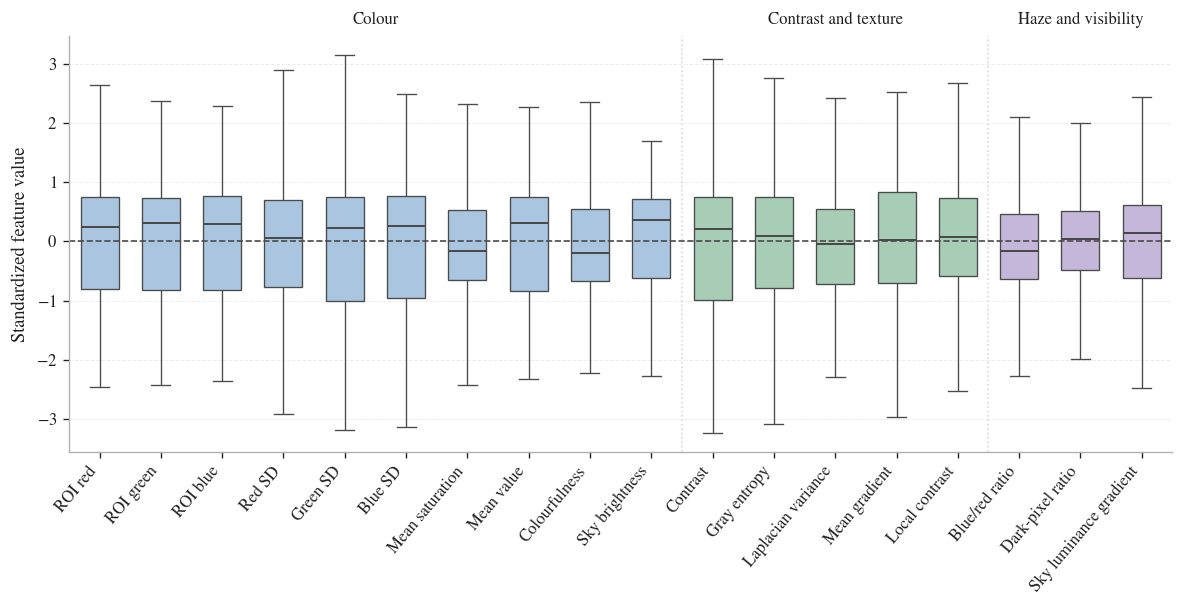

In [10]:
# Standardized distributions of handcrafted ROI image features

feature_groups = {
    "Colour": config.COLOR_FEATURES,
    "Contrast and texture": config.CONTRAST_TEXTURE_FEATURES,
    "Haze and visibility": config.HAZE_VISIBILITY_FEATURES,
}

fig, ax = features_plots.plot_standardized_feature_distributions(
    feature_data=development_df[config.IMAGE_FEATURES],
    feature_groups=feature_groups,
    output_path=RESULTS_DIR / "image_feature_distribution.png",
)

plt.show()

### 2.2 Correlation Analysis

Pearson and Spearman coefficients quantify the linear and monotonic
associations between individual image features and PM2.5.

In [11]:
# Pearson and Spearman correlations with PM2.5

correlation_results = []

for feature in config.IMAGE_FEATURES:

    pearson_r, pearson_p = pearsonr(
        development_df[feature],
        development_df[TARGET],
    )

    spearman_rho, spearman_p = spearmanr(
        development_df[feature],
        development_df[TARGET],
    )

    correlation_results.append(
        {
            "Feature": feature,
            "Pearson r": pearson_r,
            "Pearson p": pearson_p,
            "Spearman rho": spearman_rho,
            "Spearman p": spearman_p,
        }
    )

correlation_results = pd.DataFrame(
    correlation_results
)

# Rank by the stronger absolute Pearson/Spearman association
correlation_results = (
    correlation_results
    .assign(
        rank_value=lambda data: data[
            ["Pearson r", "Spearman rho"]
        ].abs().max(axis=1)
    )
    .sort_values(
        "rank_value",
        ascending=False,
    )
    .drop(
        columns="rank_value"
    )
    .reset_index(drop=True)
)

# Display only the strongest associations; the figure shows all features.
display(
    correlation_results[
        ["Feature", "Pearson r", "Spearman rho"]
    ]
    .head(10)
    .round(3)
)

correlation_results.to_csv(
    RESULTS_DIR / "image_feature_correlations.csv",
    index=False,
)

,Feature,Pearson r,Spearman rho
0,dark_pixel_ratio,-0.526,-0.451
1,local_contrast,-0.495,-0.384
2,colorfulness,-0.460,-0.450
3,B_std,-0.381,-0.299
4,mean_gradient_magnitude,-0.368,-0.270
5,laplacian_variance,-0.356,-0.279
6,gray_entropy,-0.277,-0.243
7,G_std,-0.263,-0.179
8,contrast,-0.257,-0.168
9,R_std,-0.250,-0.156


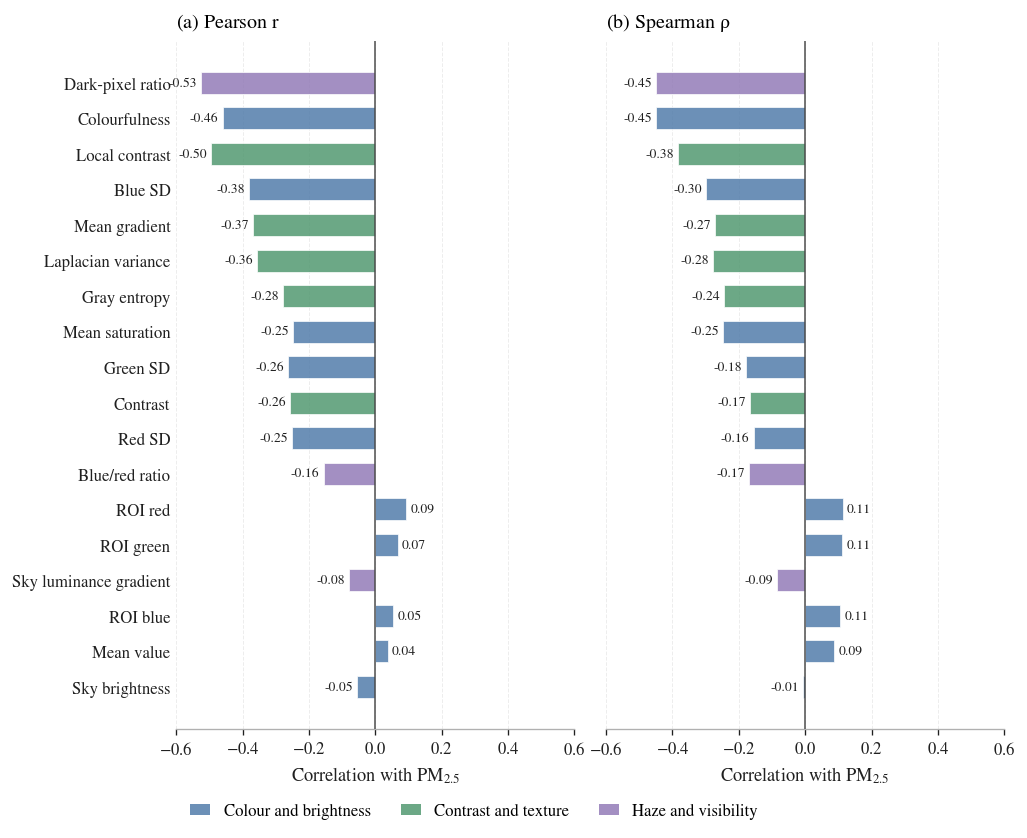

In [12]:
# Pearson and Spearman correlation comparison

fig, axes = features_plots.plot_correlation_comparison(
    correlation_results=correlation_results,
    output_path=RESULTS_DIR / "image_feature_correlation_comparison.png",
    top_n=None,
)

plt.show()

### 2.3 Image Feature Group Evaluation

Ridge and Random Forest compare the predictive value of individual image
feature groups and their combination using the same date-grouped
cross-validation folds.


In [13]:
# Define ROI image feature groups

image_feature_sets = {
    "Color": config.COLOR_FEATURES,
    "Contrast": config.CONTRAST_TEXTURE_FEATURES,
    "Visibility": config.HAZE_VISIBILITY_FEATURES,
    "All Image Features": config.IMAGE_FEATURES,
}

In [14]:
# Models used for image feature-group evaluation

feature_evaluation_models = evaluation.get_feature_evaluation_models(
    random_state=MODEL_RANDOM_STATE
)
ridge_model = feature_evaluation_models["Ridge"]
random_forest_model = feature_evaluation_models["Random Forest"]

models = {
    "Ridge": ridge_model,
    "Random Forest": random_forest_model,
}

image_group_results = []
image_group_fold_results = []

for model_name, model in models.items():

    for (
        feature_set_name,
        feature_list,
    ) in image_feature_sets.items():

        (
            summary,
            fold_results,
            _,
            _,
        ) = evaluation.evaluate_feature_set(
            model=model,
            model_name=model_name,
            feature_set_name=feature_set_name,
            feature_list=feature_list,
            development_df=development_df,

            # Not accessed because evaluate_test=False.
            test_df=final_test_df,

            target=TARGET,
            n_splits=N_SPLITS,
            random_state=MODEL_RANDOM_STATE,

            # Keep complete dates in the same fold.
            group_column="date_group",

            # Use unweighted fitting and evaluation.
            balance_column=None,

            # Feature-group evaluation uses development CV only.
            evaluate_test=False,
        )

        image_group_results.append(
            summary
        )

        image_group_fold_results.append(
            fold_results.assign(
                Model=model_name,
                **{
                    "Feature Set":
                    feature_set_name
                },
            )
        )

image_group_results = pd.concat(
    image_group_results,
    ignore_index=True,
)

image_group_fold_results = pd.concat(
    image_group_fold_results,
    ignore_index=True,
)

# Mean-prediction baseline using the same date-grouped folds
(
    image_baseline_result,
    image_baseline_fold_results,
    _,
    _,
) = evaluation.evaluate_feature_set(
    model=DummyRegressor(strategy="mean"),
    model_name="Mean Baseline",
    feature_set_name="No image information",
    feature_list=[config.IMAGE_FEATURES[0]],
    development_df=development_df,
    test_df=final_test_df,
    target=TARGET,
    n_splits=N_SPLITS,
    random_state=MODEL_RANDOM_STATE,
    group_column="date_group",
    balance_column=None,
    evaluate_test=False,
)

display(
    pd.concat(
        [image_baseline_result, image_group_results],
        ignore_index=True,
    )[
        [
            "Model",
            "Feature Set",
            "CV RMSE",
            "CV RMSE Std",
            "CV R2",
            "CV R2 Std",
        ]
    ].round(3)
)

image_group_results.to_csv(
    RESULTS_DIR / "image_group_cv_results.csv", index=False
)
image_group_fold_results.to_csv(
    RESULTS_DIR / "image_group_fold_results.csv", index=False
)
image_baseline_result.to_csv(
    RESULTS_DIR / "image_baseline_cv_result.csv", index=False
)
image_baseline_fold_results.to_csv(
    RESULTS_DIR / "image_baseline_fold_results.csv", index=False
)

,Model,Feature Set,CV RMSE,CV RMSE Std,CV R2,CV R2 Std
0,Mean Baseline,No image information,11.489,0.809,-0.016,0.022
1,Ridge,Color,8.824,0.873,0.402,0.043
2,Ridge,Contrast,9.241,0.963,0.345,0.051
3,Ridge,Visibility,9.754,0.786,0.267,0.052
4,Ridge,All Image Features,8.384,0.863,0.460,0.048
5,Random Forest,Color,8.027,0.859,0.505,0.044
6,Random Forest,Contrast,7.982,0.722,0.510,0.033
7,Random Forest,Visibility,8.626,0.998,0.429,0.063
8,Random Forest,All Image Features,7.374,0.785,0.583,0.033


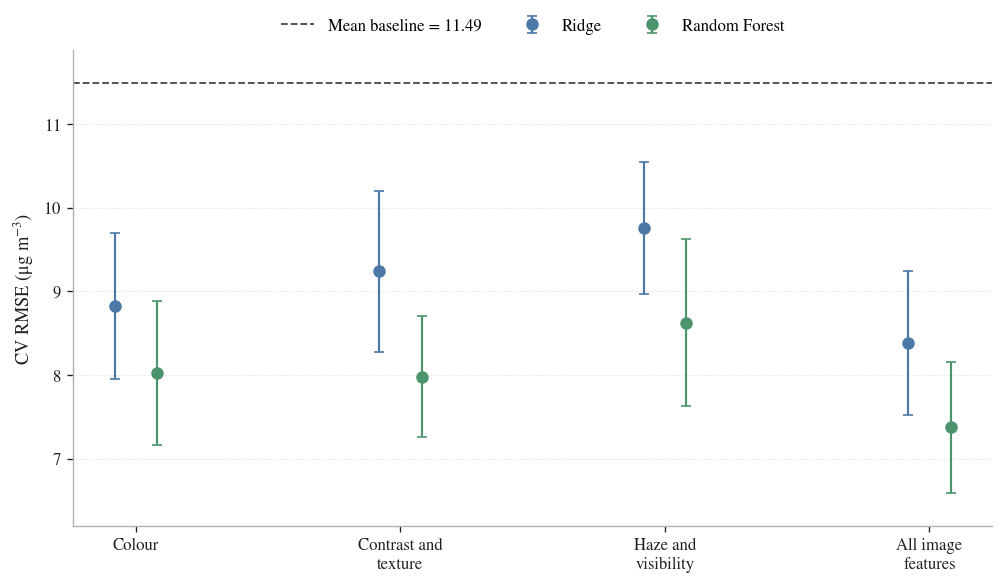

In [15]:
# Development CV performance of ROI image feature groups

fig, ax = features_plots.plot_image_feature_group_cv(
    image_group_results=image_group_results,
    baseline_value=image_baseline_result.loc[0, "CV RMSE"],
    output_path=(
        RESULTS_DIR
        / "image_feature_group_cv_rmse.png"
    ),
    metric="CV RMSE",
)

plt.show()

## 3. Multi-Source Data Fusion Evaluation

This section tests whether adding environmental, monitoring, and temporal
predictors improves estimation beyond handcrafted image features.

### 3.1 Progressive Data-Source Configurations

Four cumulative configurations progressively add ERA5, ARPA, and temporal
predictors to the image-feature baseline.

In [16]:
# Summarize progressive multi-source feature sets

fusion_feature_sets = config.FUSION_FEATURE_SETS

fusion_feature_summary = pd.DataFrame(
    {
        "Configuration": list(
            fusion_feature_sets.keys()
        ),
        "Added source": list(
            config.FEATURE_GROUPS.keys()
        ),
        "Added variables": [
            len(features)
            for features
            in config.FEATURE_GROUPS.values()
        ],
        "Total variables": [
            len(features)
            for features
            in fusion_feature_sets.values()
        ],
    }
)

display(fusion_feature_summary)

,Configuration,Added source,Added variables,Total variables
0,Image,Image,18,18
1,Image + ERA5,ERA5,18,36
2,Image + ERA5 + ARPA,ARPA,7,43
3,All Features,Temporal,12,55


### 3.2 Incremental Multi-Source Fusion

Ridge and Random Forest evaluate each cumulative configuration using the
same date-grouped cross-validation folds. Points show fold means and
error bars indicate ±1 standard deviation for RMSE and R².

In [17]:
# Evaluate progressive multi-source feature fusion

fusion_results = []
fusion_fold_results = []

for model_name, model in models.items():

    for (
        feature_set_name,
        feature_list,
    ) in fusion_feature_sets.items():

        (
            summary,
            fold_results,
            _,
            _,
        ) = evaluation.evaluate_feature_set(
            model=model,
            model_name=model_name,
            feature_set_name=feature_set_name,
            feature_list=feature_list,
            development_df=development_df,

            # Required by the interface but not accessed
            # because evaluate_test=False.
            test_df=final_test_df,

            target=TARGET,
            n_splits=N_SPLITS,
            random_state=MODEL_RANDOM_STATE,
            group_column="date_group",
            
            # Use unweighted fitting and evaluation.
            balance_column=None,
            evaluate_test=False,
        )

        fusion_results.append(
            summary
        )

        fusion_fold_results.append(
            fold_results.assign(
                Model=model_name,
                **{
                    "Feature Set":
                    feature_set_name
                },
            )
        )

fusion_results = pd.concat(
    fusion_results,
    ignore_index=True,
)

fusion_fold_results = pd.concat(
    fusion_fold_results,
    ignore_index=True,
)

display(
    fusion_results.round(
        {
            "CV MAE": 3,
            "CV MAE Std": 3,
            "CV RMSE": 3,
            "CV RMSE Std": 3,
            "CV R2": 3,
            "CV R2 Std": 3,
        }
    )
)

fusion_results.to_csv(
    RESULTS_DIR / "fusion_cv_results.csv", index=False
)
fusion_fold_results.to_csv(
    RESULTS_DIR / "fusion_fold_results.csv", index=False
)

,Model,Feature Set,Variables,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std
0,Ridge,Image,18,6.008,0.548,8.384,0.863,0.460,0.048
1,Ridge,Image + ERA5,36,5.698,0.349,7.540,0.646,0.563,0.026
2,Ridge,Image + ERA5 + ARPA,43,5.708,0.355,7.542,0.665,0.562,0.029
3,Ridge,All Features,55,5.128,0.495,6.681,0.707,0.656,0.042
4,Random Forest,Image,18,5.282,0.399,7.374,0.785,0.583,0.033
5,Random Forest,Image + ERA5,36,4.775,0.232,6.368,0.501,0.687,0.030
6,Random Forest,Image + ERA5 + ARPA,43,4.795,0.223,6.380,0.467,0.686,0.027
7,Random Forest,All Features,55,4.673,0.334,6.199,0.613,0.702,0.046


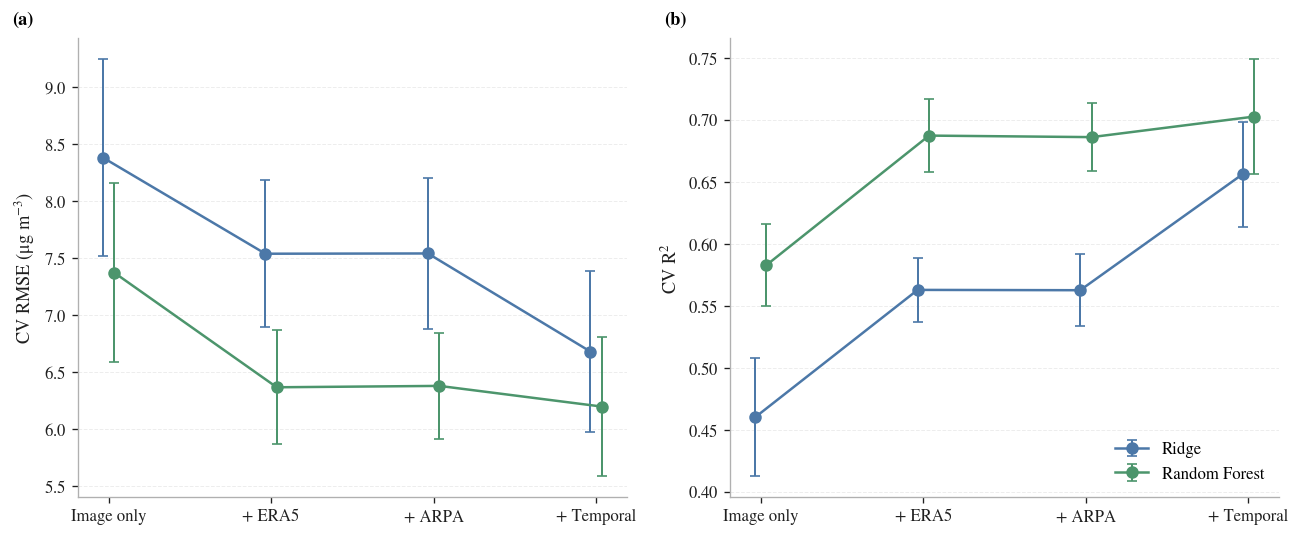

In [18]:
# Development CV performance of progressive feature fusion

fig, axes = features_plots.plot_progressive_fusion_cv(
    fusion_results=fusion_results,
    output_path=(
        RESULTS_DIR
        / "progressive_fusion_cv.png"
    ),
)

plt.show()

### 3.3 Leave-One-Source-Out Ablation

Leave-one-source-out ablation reduces dependence on the cumulative
addition order. Each source is removed from the complete Random Forest
configuration, and fold-wise ΔRMSE is measured against the complete model.
Positive ΔRMSE indicates that the removed source contributed useful
information. Small points show individual folds and diamonds show means.

In [19]:
# Define leave-one-source-out feature configurations

ablation_feature_sets = (
    evaluation.build_leave_one_source_out_sets(
        config.FEATURE_GROUPS
    )
)

In [20]:
# Evaluate leave-one-source-out ablation

(
    ablation_results,
    ablation_fold_results,
    ablation_fold_changes,
    ablation_change_summary,
) = evaluation.evaluate_leave_one_source_out(
    model=random_forest_model,
    model_name="Random Forest",
    feature_sets=ablation_feature_sets,
    development_df=development_df,
    target=TARGET,
    n_splits=N_SPLITS,
    random_state=MODEL_RANDOM_STATE,
    group_column="date_group",
)

display(ablation_change_summary.round(3))

ablation_results.to_csv(
    RESULTS_DIR / "ablation_cv_results.csv", index=False
)
ablation_fold_results.to_csv(
    RESULTS_DIR / "ablation_fold_results.csv", index=False
)
ablation_fold_changes.to_csv(
    RESULTS_DIR / "ablation_fold_changes.csv", index=False
)
ablation_change_summary.to_csv(
    RESULTS_DIR / "ablation_change_summary.csv", index=False
)


,Removed Source,RMSE Change Mean,RMSE Change Std,R2 Change Mean,R2 Change Std
0,ARPA,-0.001,0.045,-0.000,0.004
1,ERA5,0.308,0.292,-0.029,0.027
2,Image,0.651,0.242,-0.067,0.028
3,Temporal,0.182,0.241,-0.017,0.021


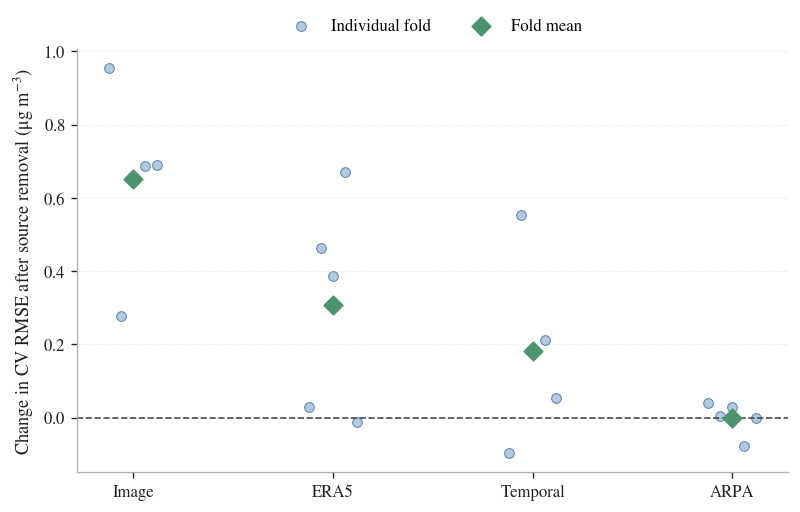

In [21]:
fig, ax = features_plots.plot_source_ablation_delta(
    ablation_fold_changes=ablation_fold_changes,
    output_path=RESULTS_DIR / "source_ablation_delta_rmse.png",
)

plt.show()